In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from utils import *
plt.rcParams['svg.fonttype'] = 'none'
import liset_data_reader.lists_sessions as lists_sessions

In [2]:
def barplot_annotate_brackets(num1, num2, data, center, height, ax, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    """ 
    Annotate barplot with p-values. 
    Adapted from the provided script.
    """
    if type(data) is str:
        text = data
    else:
        if data > 0.05:
          return
        text = ''
        p = .05
        while data < p:
            text += '*'
            p /= 10.
            if maxasterix and len(text) == maxasterix:
                break
        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    ax.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    ax.text(*mid, text, **kwargs)

In [3]:
import numpy as np

def holm_bonferroni(pvals):
    pvals = np.asarray(pvals)
    n = len(pvals)

    order = np.argsort(pvals)
    ranked = pvals[order]

    adj = (n - np.arange(n)) * ranked
    adj = np.maximum.accumulate(adj)  # enforce monotonicity
    adj = np.clip(adj, 0, 1)

    pvals_adj = np.empty_like(adj)
    pvals_adj[order] = adj #reorder to original order
    return pvals_adj

def cliffs_delta(u_stat, n_A, n_B):
     # Compute_cliff_delta:
    U1 = u_stat
    U2 = n_A * n_B - U1

    # Cliff’s delta must use U1 (vals_A vs vals_B)
    cliffs_d = (U1 - U2) / (n_A * n_B)
    # Interpretation (Romano et al., 2006)
    abs_d = abs(cliffs_d)
    if abs_d < 0.147:
        effect = "Negligible"
    elif abs_d < 0.33:
        effect = "Small"
    elif abs_d < 0.474:
        effect = "Medium"
    else:
        effect = "Large"
        
    # print(f"Cliff's Delta: {cliffs_d:.3f} ({effect})")

    return (cliffs_d,effect)

In [4]:
center="peak"
WINDOW_MS=100
filename=f"power_analysis_results_center_{center}_{WINDOW_MS}ms.pkl"
filename_properties=f"power_analysis_properties_center_{center}_{WINDOW_MS}ms.csv"

In [5]:
# Setup paths
curr_dir = os.getcwd()
# Assuming the notebook is in snnTorch/generalization_madrid
SPIKES_ROOT = os.path.join(curr_dir, "data")

DATA_FILE = os.path.join(SPIKES_ROOT, filename)

print(f"Looking for data at: {DATA_FILE}")

if not os.path.exists(DATA_FILE):
    print("Data file not found. Please run power_analysis.py first.")
else:
    with open(DATA_FILE, 'rb') as f:
        all_power_data = pickle.load(f)
    print(f"Loaded data for keys: {list(all_power_data.keys())}")

Looking for data at: c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\snnTorch\generalization_madrid\data\power_analysis_results_center_peak_100ms.pkl
Loaded data for keys: [('adapt20_3b', 20), ('dsb4updn_median_200_11b', 20), ('dsb4updn_median_200_11f', 20), ('dsb4updn_median_200_12b', 20), ('dsb4updn_median_200_13f', 20), ('dsb4updn_median_200_14b', 20), ('dsb4updn_median_200_15f', 20), ('dsb4updn_median_200_16b', 20), ('dsb4updn_median_200_9f', 20), ('updnb4ds_100_13b', 20), ('updnb4ds_100_13f', 20), ('updnb4ds_100_7', 20)]


In [6]:
hfo_sessions = lists_sessions.HFO_sessions
ripple_sessions = lists_sessions.Ripple_sessions

sessions_to_reject={
    # "2025-09-24_16-29-07", #R   # Nothing concrete to reject here
        "2025-09-24_17-38-17", # Barely any ripples (14 in total...)
        "2025-09-25_12-52-22", # Not a good session to detect ripples
        #  "2025-09-24_11-34-51",
        } #R 

sessions_to_reject.update(hfo_sessions)



In [7]:
freq=10000 # Define frequency variable
cut_snippets=50 # Define cut_snippets variable (ms)
def prepare_dataframe(all_power_data):
    records = []
    
    for (network, adapt), session in all_power_data.items():
        for session, events in session.items():
            for event_type in ['TP', 'FP', 'FN']:
                snippets = events[event_type]
                for s in snippets:
                    if len(s) == 0: continue
                    # Trim snippets
                    s = s[cut_snippets*freq//1000 : -cut_snippets*freq//1000]
                    # Calculate metrics
                    peak_power = np.max(s)
                    mean_power = np.mean(s)
                    
                    records.append({
                        'Network': network,
                        'Session': session,
                        'Adapt': adapt,
                        'Type': event_type,
                        'Peak Power': peak_power,
                        'Mean Power': mean_power,
                        'Trace': s
                    })
    
    return pd.DataFrame(records)

if os.path.exists(DATA_FILE):
    df = prepare_dataframe(all_power_data)
    print(f"Created DataFrame with {len(df)} records")
    display(df.head())
    df=df[~df["Session"].isin(sessions_to_reject)]
    print(f"After removal: {len(df)} records")


Created DataFrame with 66315 records


,Network,Session,Adapt,Type,Peak Power,Mean Power,Trace
0,adapt20_3b,2025-09-22_17-55-26,20,TP,9.864888,2.708138,"[3.4052327284022685, 3.5021138956202624, 3.602..."
1,adapt20_3b,2025-09-22_17-55-26,20,TP,12.059266,2.040872,"[-0.31371585732038276, -0.31385211435765376, -..."
2,adapt20_3b,2025-09-22_17-55-26,20,TP,13.163351,3.501249,"[-0.18382208648871454, -0.17889184644622041, -..."
3,adapt20_3b,2025-09-22_17-55-26,20,TP,12.245096,1.781635,"[0.17378086405698698, 0.15713432700277294, 0.1..."
4,adapt20_3b,2025-09-22_17-55-26,20,TP,3.849110,1.207716,"[-0.10341269078306599, -0.10350445127559557, -..."


After removal: 66315 records


In [8]:
stats_df=df.copy()
measures=['Peak Power', 'Mean Power']

# Create a summary table with mean, std, and count for each measure
summary_table = stats_df.groupby("Type")[measures].agg(['mean', 'median','std', 'count']).round(2)

display(summary_table)

Peak Power                      Mean Power                    
           mean median    std  count       mean median   std  count
Type                                                               
FN         6.74   5.24   5.21   7362       1.11   0.87  0.94   7362
FP         5.81   4.35   5.06  33687       1.01   0.75  1.16  33687
TP        16.08  12.78  11.57  25266       3.21   2.49  2.51  25266

In [9]:
from scipy.stats import mannwhitneyu, wilcoxon

def perform_statistical_comparison(group1, group2, paired=False):
    """
    Performs statistical comparison between two groups.
    """
    if len(group1) == 0 or len(group2) == 0:
        return None, None, None

    if paired:
        if isinstance(group1, pd.Series) and isinstance(group2, pd.Series):
             # Align by index (Session)
            common_indices = group1.index.intersection(group2.index)
            g1_aligned = group1.loc[common_indices]
            g2_aligned = group2.loc[common_indices]
            
            if len(g1_aligned) == 0:
                 return None, None, None
                 
            try:
                stat, p = wilcoxon(g1_aligned, g2_aligned)
                test_name = "Wilcoxon"
            except ValueError:
                 # Can happen if all differences are zero
                return None, 1.0, "Wilcoxon"
            
            cliff_d, effect = cliffs_delta(stat, len(g1_aligned), len(g2_aligned))
            return p, cliff_d, test_name, effect
            
    # Independent (Mann-Whitney U)
    stat, p = mannwhitneyu(group1, group2)
    test_name = "Mann-Whitney"
    cliff_d, effect = cliffs_delta(stat, len(group1), len(group2))
    
    return p, cliff_d, test_name, effect

def plot_power(vtype="Peak Power", aggregate_by=None, ylim=None, figsize=(6,6)):
    if not os.path.exists(DATA_FILE) or df.empty:
        return

    df_plot = df.copy()
    is_paired = False

    if aggregate_by is not None:
        aggregation_vars = ["Type"] + aggregate_by
        # If aggregating by Session, we set index to Session for later alignment
        if "Session" in aggregate_by:
             df_plot = df_plot.groupby(aggregation_vars)[vtype].median().reset_index()
             df_plot.set_index("Session", inplace=True) # Set index for alignment in stats
             is_paired = True
        else:
             df_plot = df_plot.groupby(aggregation_vars)[vtype].median().reset_index()

    fig, ax = plt.subplots(figsize=figsize)
    
    # Define order for consistency
    order = ['TP', 'FP', 'FN']
    colors = {'TP': 'green', 'FP': 'red', 'FN': 'blue'}
    
    # Reset index for plotting to avoid issues with seaborn
    plot_data = df_plot.reset_index() if is_paired else df_plot
    
    # Aggregate plot
    sns.violinplot(data=plot_data, x='Type', y=vtype, order=order, inner="quartile", ax=ax, palette=colors, alpha=0.3, linecolor="black", linewidth=1.4)
    if is_paired:
        sns.stripplot(data=plot_data, x='Type', y=vtype, order=order, ax=ax, color="black", alpha=0.2, jitter=True, s=3)

    print(f"Statistical Significance ({'Paired' if is_paired else 'Independent'}) - {vtype}:")
    

    tp_vals = df_plot[df_plot['Type'] == 'TP'][vtype] if 'Type' in df_plot.columns else df_plot[df_plot.index.get_level_values('Type') == 'TP'][vtype] # Handle if Type became index
    
    # Re-extract from plot_data (which is reset) but set index back if needed for stats
    if is_paired:
        tp_vals = plot_data[plot_data['Type'] == 'TP'].set_index("Session")[vtype]
        fp_vals = plot_data[plot_data['Type'] == 'FP'].set_index("Session")[vtype]
        fn_vals = plot_data[plot_data['Type'] == 'FN'].set_index("Session")[vtype]
    else:
        tp_vals = plot_data[plot_data['Type'] == 'TP'][vtype]
        fp_vals = plot_data[plot_data['Type'] == 'FP'][vtype]
        fn_vals = plot_data[plot_data['Type'] == 'FN'][vtype]

    # Prepare heights and centers for annotation
    max_tp = tp_vals.quantile(0.99) if not tp_vals.empty else 0
    max_fp = fp_vals.quantile(0.99) if not fp_vals.empty else 0
    max_fn = fn_vals.quantile(0.99) if not fn_vals.empty else 0
    
    heights = [max_tp, max_fp, max_fn]
    centers = [0, 1, 2]

    p_vals = []
    comparisons = []
    
    pairs = [
        (tp_vals, fp_vals, 0, 1, f"TP({len(tp_vals)}) vs FP({len(fp_vals)})"),
        (fp_vals, fn_vals, 1, 2, f"FP({len(fp_vals)}) vs FN({len(fn_vals)})"),
        (tp_vals, fn_vals, 0, 2, f"TP({len(tp_vals)}) vs FN({len(fn_vals)})")
    ]

    for g1, g2, idx1, idx2, label in pairs:
        p, cliff, test,effect = perform_statistical_comparison(g1, g2, paired=is_paired)
        if p is not None:
            print(f"{label} ({test}): p={p:.4e}, Cliff's d={cliff:.3f} ({effect})")
            p_vals.append(p)
            comparisons.append((idx1, idx2, label))

    # Apply Holm-Bonferroni correction
    if p_vals:
        p_vals_adj = holm_bonferroni(p_vals)
        
        for i, p in enumerate(p_vals_adj):
            heights = [h + 0.025 * (i) * h for h in heights] # Increase height spacing
            idx1, idx2, label = comparisons[i]
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            # print(f"{label} (Adj): p-value = {p:.4e} ({sig})")
            barplot_annotate_brackets(idx1, idx2, p, centers, heights, ax, barh=0.00, maxasterix=3)

    ax.set_title(f'{vtype} Distribution', fontsize=16)
    ax.set_ylabel(f'{vtype} (z-score)', fontsize=14)
    ax.set_xlabel('', fontsize=14)
    ax.spines[['left', 'bottom', 'right', 'top']].set_linewidth(1.3)
    ax.spines[['right', 'top']].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=13)
    
    if ylim:
        ax.set_ylim(ylim)
    ax.grid(False)
    
    plt.tight_layout()
    plt.show()
    return fig, ax

Statistical Significance (Paired) - Peak Power:
TP(23) vs FP(23) (Wilcoxon): p=2.3842e-07, Cliff's d=-1.000 (Large)
FP(23) vs FN(23) (Wilcoxon): p=3.9307e-01, Cliff's d=-0.588 (Large)
TP(23) vs FN(23) (Wilcoxon): p=2.3842e-07, Cliff's d=-1.000 (Large)


C:\Users\NCN\AppData\Local\Temp\ipykernel_9560\1790653393.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='Type', y=vtype, order=order, inner="quartile", ax=ax, palette=colors, alpha=0.3, linecolor="black", linewidth=1.4)


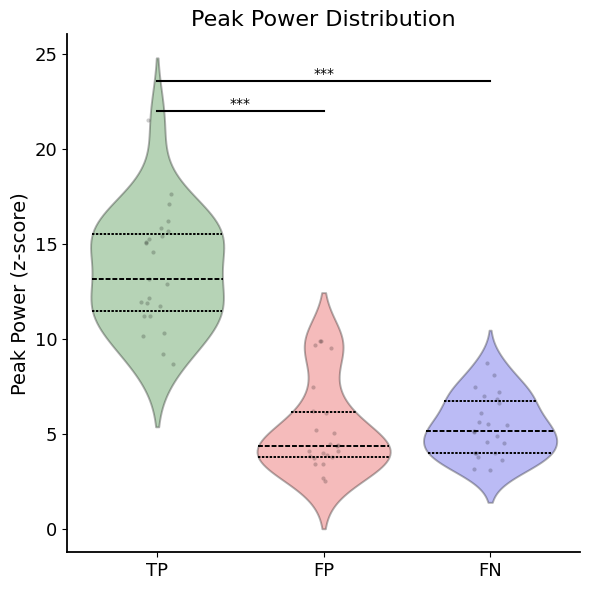

In [10]:
aggregate_by=["Session"]
# aggregate_by=None
# y_lim=(None, 60)
y_lim=None
fig,ax=plot_power(vtype="Peak Power",aggregate_by=aggregate_by, ylim=y_lim)
# fig.savefig("figures/peak_power_violin_plot2.svg")

Statistical Significance (Paired) - Mean Power:
TP(23) vs FP(23) (Wilcoxon): p=2.3842e-07, Cliff's d=-1.000 (Large)
FP(23) vs FN(23) (Wilcoxon): p=3.6039e-01, Cliff's d=-0.595 (Large)
TP(23) vs FN(23) (Wilcoxon): p=2.3842e-07, Cliff's d=-1.000 (Large)


C:\Users\NCN\AppData\Local\Temp\ipykernel_9560\1790653393.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='Type', y=vtype, order=order, inner="quartile", ax=ax, palette=colors, alpha=0.3, linecolor="black", linewidth=1.4)


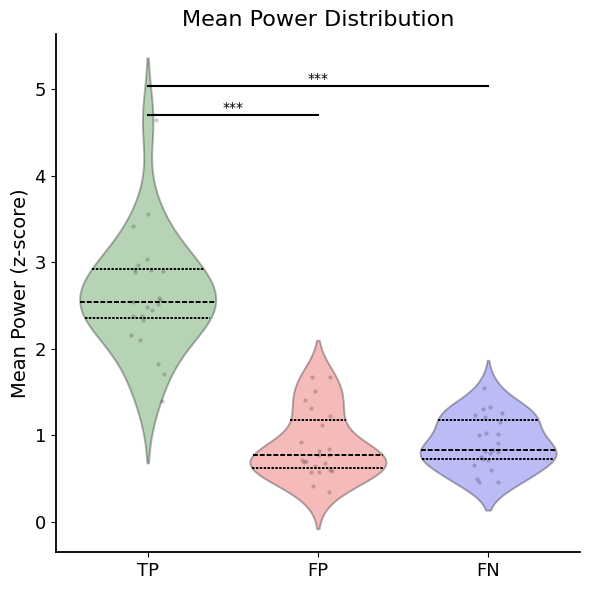

In [11]:
# y_lim=(-2, 15)
y_lim=None
fig,ax=plot_power(vtype="Mean Power",aggregate_by=aggregate_by, ylim=y_lim)
# fig.savefig("figures/mean_power_violin_plot2.svg")

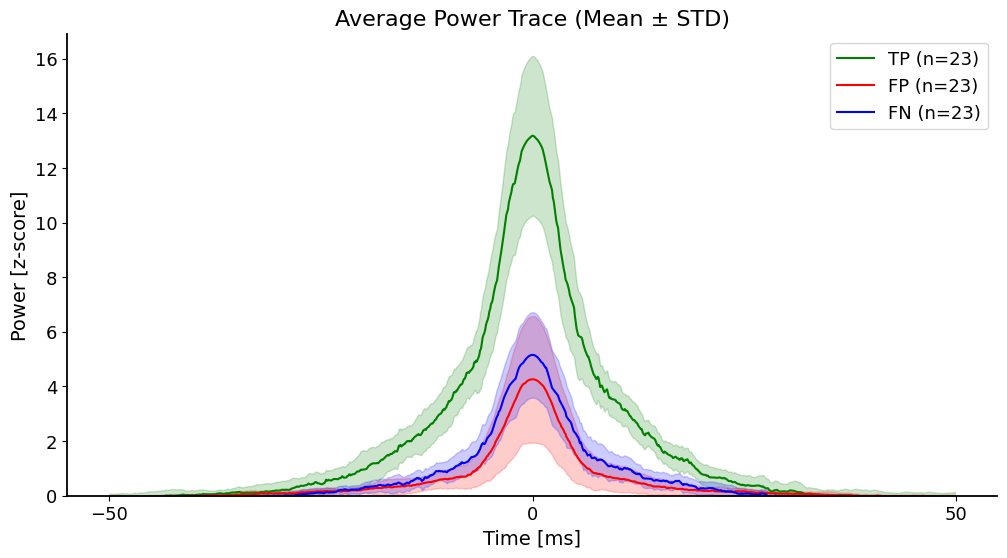

In [13]:
# 3. Power Trace Analysis (Whole Window)
if os.path.exists(DATA_FILE) and not df.empty:
    # Function to plot traces with CI
    def plot_traces(data_df, title_suffix="",aggregate_by=None):
        fig,ax=plt.subplots(figsize=(12,6))
        
        event_types = ['TP', 'FP', 'FN']
        colors = {'TP': 'green', 'FP': 'red', 'FN': 'blue'}
        
        # Check trace length from first record
        trace_len = len(data_df.iloc[0]['Trace'])

        x_axis = np.arange(trace_len)/10-50  # Convert to milliseconds, centered at 0
        
        for et in event_types:
            subset = data_df[data_df['Type'] == et]
            if subset.empty: continue
            if aggregate_by is not None:
                aggregation_vars=["Type"]
                aggregation_vars.extend(aggregate_by)
                subset = subset.groupby(aggregation_vars)['Trace'].apply(lambda x: np.median(np.stack(x.values), axis=0)).reset_index()
            
            # Stack traces: (N_samples, Time_points)
            traces = np.stack(subset['Trace'].values)
            
            # mean_trace = np.mean(traces, axis=0)
            mean_trace = np.median(traces, axis=0)
            std_trace = np.std(traces, axis=0)
            
            # 95% CI approx
            ci = 1.96 * std_trace / np.sqrt(len(traces))
            
            # Using STD for visualization as requested
            upper = mean_trace + std_trace
            lower = mean_trace - std_trace
            lower = np.maximum(lower, 0)
            
            ax.plot(x_axis, mean_trace, label=f'{et} (n={len(traces)})', color=colors[et])
            ax.fill_between(x_axis, lower, upper, color=colors[et], alpha=0.2)
            
        ax.set_title(f'Average Power Trace (Mean ± STD)',fontsize=16)
        ax.set_xlabel('Time [ms]', fontsize=14)
        ax.set_ylabel('Power [z-score]', fontsize=14)
        ax.legend(fontsize=13)
        # ax.grid(True, alpha=0.2)
        ax.grid(False)
        # ax.set_xticks(np.arange(-100, 101, 50))
        ax.set_xticks(np.arange(-50, 51, 50))
        ax.tick_params(axis='both', which='major', labelsize=13)
        ax.spines[['left', 'bottom', 'right', 'top']].set_linewidth(1.3)
        ax.spines[['right', 'top']].set_visible(False)
        ax.set_ylim(bottom=0)
        plt.show()
        return fig,ax

    # Plot aggregated across all networks/adapts
    fig,ax=plot_traces(df, title_suffix="(Aggregated)",aggregate_by=aggregate_by)
    fig.savefig("figures/power_traces_aggregated2.svg")

# Event Properties

In [14]:
# read csv with properties
properties_file=os.path.join(SPIKES_ROOT, filename_properties)
if os.path.exists(properties_file):
    properties_df = pd.read_csv(properties_file)
    print(f"Loaded properties from {properties_file}")
    display(properties_df.head())

Loaded properties from c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\snnTorch\generalization_madrid\data\power_analysis_properties_center_peak_100ms.csv


,Session,Network,Adapt,Event_Idx,Event_Type,Duration_ms,Preferred_Freq,Low_Freq_Contrib,Entropy,Spike_Number,Spike_Rate,Spike_Number_within_Event,Spike_Rate_within_Event
0,2025-09-22_17-55-26,adapt20_3b,20,0,TP,76.833333,134.0,0.866152,3.701407,39.0,390.0,43.0,559.652928
1,2025-09-22_17-55-26,adapt20_3b,20,1,TP,56.633333,132.0,0.830454,3.895311,27.0,270.0,27.0,476.751030
2,2025-09-22_17-55-26,adapt20_3b,20,2,TP,76.833333,168.0,0.899712,3.952858,38.0,380.0,34.0,442.516269
3,2025-09-22_17-55-26,adapt20_3b,20,3,TP,39.700000,138.0,0.822485,3.594247,26.0,260.0,20.0,503.778338
4,2025-09-22_17-55-26,adapt20_3b,20,4,TP,48.200000,114.0,0.948410,3.397240,26.0,260.0,24.0,497.925311


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import numpy as np

def plot_event_properties(df, 
                          properties=['Duration_ms', 'Preferred_Freq', 'Low_Freq_Contrib', 'Entropy', 'Spike_Rate', 'Spike_Rate_within_Event'],
                          x='Event_Type', 
                          hue=None, 
                          aggregate_by=None, 
                          order=None, 
                          hue_order=None,
                          title_suffix="",):
    """
    Plots properties of events with options for aggregation.
    
    Args:
        df: DataFrame containing the data.
        properties: List of column names to plot.
        x: Column for x-axis (e.g., 'Event_Type', 'Network').
        hue: Column for color grouping (e.g., 'Network').
        aggregate_by: List of columns to aggregate by (e.g. ['Session']). 
                      If provided, the data will be averaged over these groups (preserving x and hue).
                      If None, individual events are plotted.
    """
    df_plot = df.copy()
    
    # Define color scheme for Event Types
    colors = {'TP': 'green', 'FP': 'red', 'FN': 'blue'}
    palette = None
    
    # Determine appropriate palette
    if hue == 'Event_Type':
        palette = colors
    elif x == 'Event_Type' and hue is None:
        palette = colors

    # --- Aggregation ---
    if aggregate_by is not None:
        # Construct group keys: x, hue (if present), and aggregation columns
        group_keys = set(aggregate_by)
        if x in df_plot.columns: group_keys.add(x)
        if hue and hue in df_plot.columns: group_keys.add(hue)
        
        group_keys = list(group_keys)
        
        print(f"Aggregating data by {group_keys}...")
        
        # Select numeric columns for median
        numeric_cols = df_plot.select_dtypes(include=[np.number]).columns.tolist()
        
        # Groupby
        df_plot = df_plot.groupby(group_keys)[numeric_cols].median().reset_index()
        title_suffix += f" (Aggregated by {aggregate_by})"
    else:
        title_suffix += " (All Events)"

    # --- Plotting ---
    n_props = len(properties)
    fig, axes = plt.subplots(1, n_props, figsize=(4*n_props, 5))
    if n_props == 1: axes = [axes]
    
    for i, prop in enumerate(properties):
        if prop not in df_plot.columns:
            print(f"Skipping {prop} (not in columns)")
            continue
            
        ax = axes[i]
        
        # Plot
        sns.violinplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, inner="quart", alpha=0.3, cut=0, palette=palette)
        # sns.stripplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, dodge=True, ax=ax, alpha=0.6, jitter=True, size=4, legend=False, palette=palette)
        
        # --- Simple Stats (Mann-Whitney) for 2 groups ---
        # Only do stats if we have meaningful x grouping and no hue (comparing x bins)
        if hue is None and x in df_plot.columns:
            levels = order if order else sorted(df_plot[x].dropna().unique())
            if len(levels) == 2:
                g1 = df_plot[df_plot[x] == levels[0]][prop].dropna()
                g2 = df_plot[df_plot[x] == levels[1]][prop].dropna()
                if len(g1) > 0 and len(g2) > 0:
                    _, p = mannwhitneyu(g1, g2)
                    # Annotate
                    y_max = df_plot[prop].max()
                    ax.text(0.5, y_max, f"p={p:.4f}", ha='center', va='bottom', transform=ax.get_xaxis_transform())

        # ax.set_title(prop, fontsize=12)
        ax.set_xlabel(x)
        ax.set_ylabel(prop)
    
    plt.suptitle(f'Event Properties{title_suffix}', fontsize=14)
    plt.tight_layout()
    plt.show()
    return fig

C:\Users\NCN\AppData\Local\Temp\ipykernel_9560\1359621637.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, inner="quart", alpha=0.3, cut=0, palette=palette)
C:\Users\NCN\AppData\Local\Temp\ipykernel_9560\1359621637.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, inner="quart", alpha=0.3, cut=0, palette=palette)
C:\Users\NCN\AppData\Local\Temp\ipykernel_9560\1359621637.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `lege

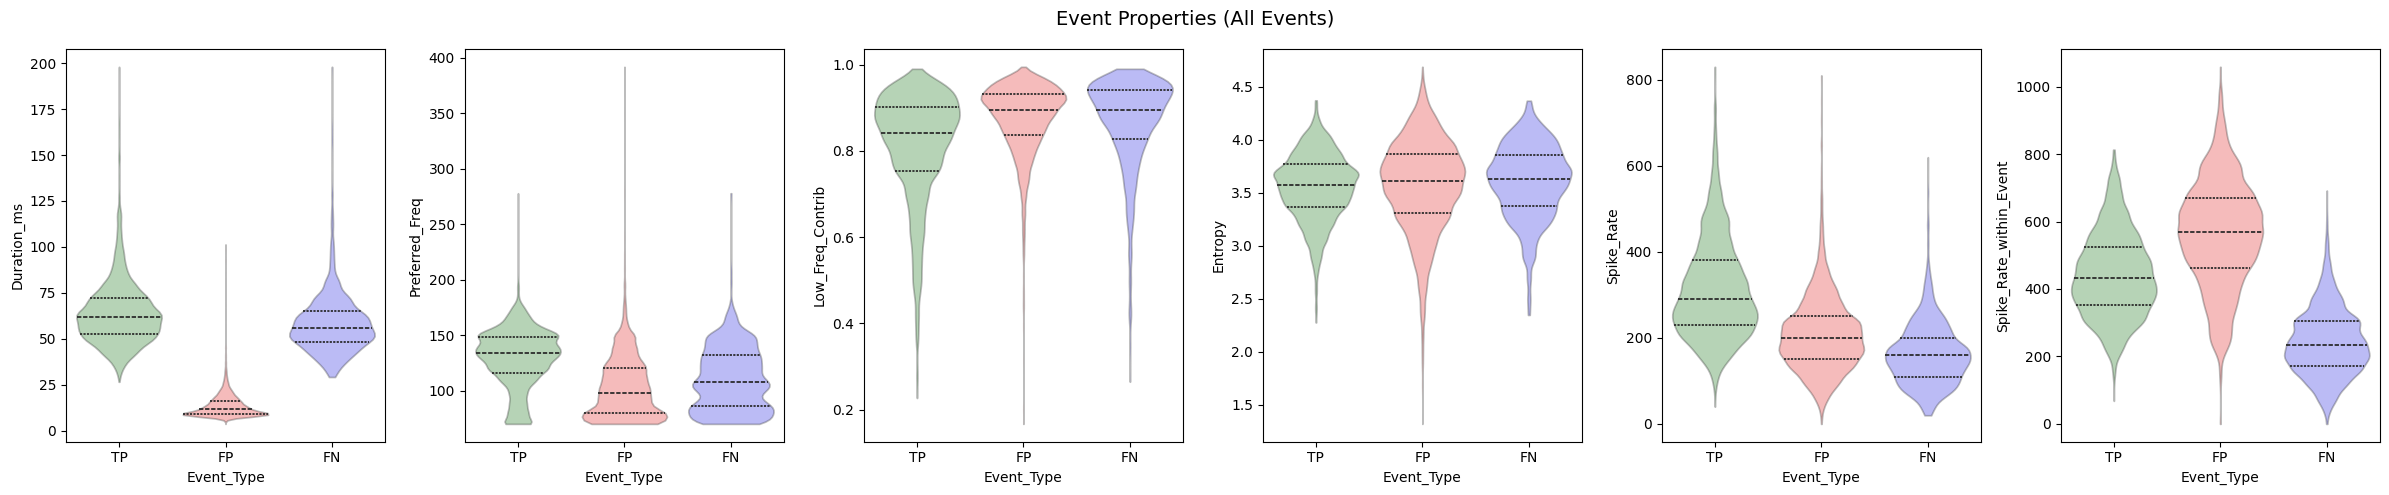

In [16]:
aggregate_by=None
fig=plot_event_properties(properties_df, 
                        properties=['Duration_ms', 'Preferred_Freq', 'Low_Freq_Contrib', 'Entropy', 'Spike_Rate', 'Spike_Rate_within_Event'],
                        x='Event_Type', 
                        hue=None, 
                        aggregate_by=aggregate_by, 
                        order=["TP", "FP", "FN"], 
                        hue_order=None,
                        title_suffix="",)

In [17]:
def get_property_summary_table(df, group_col="Event_Type", properties=None, aggregate_by=None):
    """
    Generates a summary table comparing groups in group_col.
    Supports aggregation via aggregate_by (e.g., ['Session']).
    
    Args:
        df: DataFrame containing the data.
        group_col: Column to group by for the summary columns (e.g. 'Event_Type' or 'Network').
        properties: List of properties to summarize. 
        aggregate_by: List of columns to aggregate (mean) by before summarizing. 
                      e.g. ['Session'] will compute the mean per session for each group in group_col, 
                      and then summarize the distribution of session means.
    """
    if properties is None:
        properties = ['Duration_ms', 'Preferred_Freq', 'Low_Freq_Contrib', 'Entropy', 'Spike_Rate', 'Spike_Rate_within_Event']

    df_plot = df.copy()

    # --- Aggregation ---
    if aggregate_by:
        group_keys = set(aggregate_by)
        if group_col in df_plot.columns: group_keys.add(group_col)
        group_keys = list(group_keys)
        print(f"Aggregating data by {group_keys}...")
        numeric_cols = df_plot.select_dtypes(include=[np.number]).columns.tolist()
        df_plot = df_plot.groupby(group_keys)[numeric_cols].mean().reset_index()

    # Get Groups
    if group_col not in df_plot.columns:
        print(f"Group column '{group_col}' not found.")
        return pd.DataFrame()
        
    groups = sorted(df_plot[group_col].dropna().unique())
    print(f"Comparing groups in '{group_col}': {groups}")

    summary_rows = []
    
    for prop in properties:
        if prop not in df_plot.columns: continue
        
        row_stats = {"Property": prop}
        group_vectors = {}

        for g in groups:
            data = df_plot[df_plot[group_col] == g][prop].dropna()
            group_vectors[g] = data
            
            median = data.median()
            std = data.std()
            count = len(data)
            row_stats[str(g)] = f"{median:.2f} ± {std:.2f} (n={count})"

        # Parameterized Stats (pairwise if 2 groups)
        if len(groups) == 2:
            g1, g2 = groups[0], groups[1]
            d1, d2 = group_vectors[g1], group_vectors[g2]
            if len(d1) > 0 and len(d2) > 0:
                _, p = mannwhitneyu(d1, d2)
                row_stats["p-value"] = p
            else:
                row_stats["p-value"] = np.nan
             
        summary_rows.append(row_stats)

    summary_df = pd.DataFrame(summary_rows)
    
    # Format p-value if exists
    if "p-value" in summary_df.columns:
        def format_p(p):
            if pd.isna(p): return "-"
            sig = ""
            if p < 0.05: sig = "*"
            if p < 0.01: sig = "**"
            if p < 0.001: sig = "***"
            if p < 0.001: return f"{p:.2e} {sig}"
            return f"{p:.4f} {sig}"
        summary_df["p-value (MWU)"] = summary_df["p-value"].apply(format_p)
        summary_df.drop(columns=["p-value"], inplace=True)
        
    return summary_df

get_property_summary_table(properties_df, group_col="Event_Type", properties=['Duration_ms', 'Preferred_Freq', 'Low_Freq_Contrib', 'Entropy', 'Spike_Rate', 'Spike_Rate_within_Event'], aggregate_by=aggregate_by)

Comparing groups in 'Event_Type': ['FN', 'FP', 'TP']


,Property,FN,FP,TP
0,Duration_ms,56.00 ± 16.39 (n=7362),11.87 ± 6.53 (n=33700),61.87 ± 17.68 (n=25266)
1,Preferred_Freq,108.00 ± 27.96 (n=7362),98.00 ± 27.11 (n=33700),134.00 ± 25.88 (n=25266)
2,Low_Freq_Contrib,0.89 ± 0.11 (n=7362),0.89 ± 0.08 (n=33700),0.84 ± 0.13 (n=25266)
3,Entropy,3.63 ± 0.35 (n=7362),3.61 ± 0.44 (n=33700),3.58 ± 0.32 (n=25266)
4,Spike_Rate,160.00 ± 72.15 (n=7362),200.00 ± 87.31 (n=33700),290.00 ± 116.15 (n=25266)
5,Spike_Rate_within_Event,233.31 ± 99.09 (n=7362),569.88 ± 158.39 (n=33700),432.00 ± 124.14 (n=25266)


# Single Property

In [18]:
from scipy.stats import mannwhitneyu, wilcoxon
import itertools

def plot_single_property(df, 
                         prop, 
                         x='Event_Type', 
                         hue=None, 
                         aggregate_by=None, 
                         order=None, 
                         hue_order=None,
                         title_suffix="",
                         ax=None,
                         y_label=None,
                         figsize=(6,6),y_lim=None, boxplot=False):
    """
    Plots a single property with detailed pairwise statistical comparisons.
    Uses Wilcoxon signed-rank test for aggregated (paired) data, and Mann-Whitney U for independent data.
    """
    df_plot = df.copy()
    
    # Define color scheme for Event Types
    colors = {'TP': 'green', 'FP': 'red', 'FN': 'blue'}
    palette = None
    if hue == 'Event_Type' or (x == 'Event_Type' and hue is None):
        palette = colors

    # --- Aggregation ---
    is_paired = False
    if aggregate_by is not None:
        group_keys = set(aggregate_by)
        if x in df_plot.columns: group_keys.add(x)
        if hue and hue in df_plot.columns: group_keys.add(hue)
        group_keys = list(group_keys)
        numeric_cols = df_plot.select_dtypes(include=[np.number]).columns.tolist()
        df_plot = df_plot.groupby(group_keys)[numeric_cols].median().reset_index()
        title_suffix += f" (Aggregated by {aggregate_by})"
        is_paired = True

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    # Plot
    if not boxplot:
        sns.violinplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, inner="quart", alpha=0.3, cut=0, palette=palette)
    else:
        sns.boxplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, palette=palette,boxprops=dict(alpha=.3),showfliers=False )
    if aggregate_by is not None:
        sns.stripplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, alpha=0.6, jitter=True, size=4, legend=False, palette=palette)

    # --- Statistical Testing (Pairwise) ---
    # Currently only implemented for 'x' categories when hue is None
    if hue is None and x in df_plot.columns:
        levels = order if order else sorted(df_plot[x].dropna().unique())
        n_levels = len(levels)
        
        if n_levels > 1:
            p_vals = []
            comparisons = []
            
            # Prepare heights for brackets based on the max value in each group
            # (Calculation repeated for visualization context, though not efficient)
            vectors_for_height = [df_plot[df_plot[x] == l][prop].dropna() for l in levels]
            centers = range(n_levels)
            heights = [v.max() if len(v) > 0 else 0 for v in vectors_for_height]

            # Generate all pairs
            for i, j in itertools.combinations(range(n_levels), 2):
                l1, l2 = levels[i], levels[j]
                
                p = np.nan
                stat_name = ""

                if is_paired:
                    # --- Wilcoxon Signed-Rank Test (Paired) ---
                    # Merge on aggregation keys to align subjects
                    merge_keys = [k for k in aggregate_by if k != x] if aggregate_by else []
                    
                    if merge_keys:
                        d1 = df_plot[df_plot[x] == l1]
                        d2 = df_plot[df_plot[x] == l2]
                        
                        # Inner merge ensures we only compare subjects present in both groups
                        merged = pd.merge(d1, d2, on=merge_keys, suffixes=('_1', '_2'), how='inner')
                        v1 = merged[prop + '_1'].dropna()
                        v2 = merged[prop + '_2'].dropna()
                        
                        if len(v1) > 0:
                            try:
                                # wilcoxon requires non-zero differences for valid p-value in some versions, 
                                # or throws error if inputs are empty
                                u, p = wilcoxon(v1, v2)
                                cliff_delta,effect=cliffs_delta(u, len(v1), len(v2))
                                print(f"{l1} vs {l2}: Cliff's Delta = {cliff_delta:.3f} ({effect})")
                            except ValueError:
                                # e.g. "zero_method 'wilcox' and 'pratt' do not work if x - y is zero for all elements."
                                p = 1.0 
                            stat_name = "Wilcox"
                else:
                    # --- Mann-Whitney U Test (Independent) ---
                    v1 = df_plot[df_plot[x] == l1][prop].dropna()
                    v2 = df_plot[df_plot[x] == l2][prop].dropna()
                    
                    if len(v1) > 0 and len(v2) > 0:
                        u, p = mannwhitneyu(v1, v2)
                        stat_name = "MWU"
                        cliff_delta,effect=cliffs_delta(u, len(v1), len(v2))
                        print(f"{l1} vs {l2}: Cliff's Delta = {cliff_delta:.3f} ({effect})")

                if not np.isnan(p):
                    p_vals.append(p)
                    # Label for debugging or printing
                    label = f"{l1} vs {l2} ({stat_name})"
                    comparisons.append((i, j, label))

            # Correction and plotting
            if p_vals:
                p_vals_adj = holm_bonferroni(p_vals)
                
                current_height_offset = 0
                max_h = max(heights) if heights else 0
                
                # Determine scaling for brackets
                y_min = df_plot[prop].min() if not df_plot.empty else 0
                y_max = df_plot[prop].max() if not df_plot.empty else 1
                y_range = y_max - y_min
                if y_range == 0: y_range = 1
                
                # Plot brackets
                for k, p_adj in enumerate(p_vals_adj):
                    idx1, idx2, label = comparisons[k]
                    print(f"{label}: p-value = {p_vals[k]:.4e} -> adj p-value = {p_adj:.4e}")

                    if p_adj < 0.05: # Only plot significant
                        # Find base height for this bracket (above the highest violin of the pair)
                        h_pair_max = max(heights[idx1], heights[idx2])
                        
                        # Stack: Base + fixed clearance + accumulated offset
                        h = h_pair_max + y_range*0.1 + current_height_offset
                        
                        # Annotate
                        sig = '***' if p_adj < 0.001 else '**' if p_adj < 0.01 else '*'
                        # print(f"  {label}: p={p_vals[k]:.4e} -> adj={p_adj:.4e} ({sig})")
                        
                        # barplot_annotate_brackets(idx1, idx2, p_adj, centers, [h]*n_levels, ax, barh=0.01, maxasterix=3)
                        
                        # Push next bracket up
                        current_height_offset += y_range * 0.12
                
                # Adjust final ylim to fit all brackets
                # ax.set_ylim(top=max_h + y_range*0.2 + current_height_offset)

    # ax.set_title(f'{prop} {title_suffix}', fontsize=12)
    ax.set_ylabel(f"{y_label}" if y_label else prop)
    ax.set_xlabel("")

    if y_lim is not None:
        ax.set_ylim(y_lim)

    ax.spines[['left', 'bottom', 'right', 'top']].set_linewidth(2)
    ax.spines[['right', 'top']].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=13)

    # ax.grid(True, alpha=0.1)
    ax.grid(False)
    plt.tight_layout()
    return fig



In [19]:
def get_single_property_summary(df, prop, group_col="Event_Type", aggregate_by=None):
    """
    Generates a detailed summary table for a single property, including Quartiles (25%-75%) and p-values.
    
    Args:
        df: DataFrame containing the data.
        prop: The property to summarize (e.g. 'Duration_ms').
        group_col: Column to group by (e.g. 'Event_Type').
        aggregate_by: List of columns to aggregate (mean) by before summarizing. 
    """
    df_plot = df.copy()

    # --- Aggregation ---
    is_paired = False
    if aggregate_by:
        group_keys = set(aggregate_by)
        if group_col in df_plot.columns: group_keys.add(group_col)
        group_keys = list(group_keys)
        numeric_cols = df_plot.select_dtypes(include=[np.number]).columns.tolist()
        df_plot = df_plot.groupby(group_keys)[numeric_cols].median().reset_index()
        is_paired = True
        print(f"Aggregating by {aggregate_by} -> N={len(df_plot)}")

    if prop not in df_plot.columns:
        print(f"Property '{prop}' not found.")
        return pd.DataFrame()
        
    groups = sorted(df_plot[group_col].unique())
    
    # 1. Descriptive Stats Rows
    stats_data = []
    
    for g in groups:
        data = df_plot[df_plot[group_col] == g][prop].dropna()
        
        q25 = data.quantile(0.25)
        median = data.median()
        q75 = data.quantile(0.75)
        mean = data.mean() # Optional
        std = data.std()
        n = len(data)
        
        stats_data.append({
            "Group": g,
            "Median [IQR]": f"{median:.2f} [{q25:.2f}, {q75:.2f}]",
            "Mean ± Std": f"{mean:.2f} ± {std:.2f}",
            "N": n
        })
        
    summary_df = pd.DataFrame(stats_data)
    
    # 2. Pairwise Comparisons
    # Add columns for each pair comparison p-value
    import itertools
    pairs = list(itertools.combinations(groups, 2))
    p_vals_dict = {}

    for g1, g2 in pairs:
        label = f"p({g1} vs {g2})"
        p = np.nan
        
        if is_paired:
            # Paired -> Wilcoxon
            merge_keys = [k for k in aggregate_by if k != group_col] if aggregate_by else []
            if merge_keys:
                d1 = df_plot[df_plot[group_col] == g1]
                d2 = df_plot[df_plot[group_col] == g2]
                merged = pd.merge(d1, d2, on=merge_keys, suffixes=('_1', '_2'), how='inner')
                v1 = merged[prop + '_1'].dropna()
                v2 = merged[prop + '_2'].dropna()
                
                if len(v1) > 0:
                    try:
                        _, p = wilcoxon(v1, v2)
                    except ValueError:
                        p = 1.0
        else:
             # Independent -> Mann-Whitney
            v1 = df_plot[df_plot[group_col] == g1][prop].dropna()
            v2 = df_plot[df_plot[group_col] == g2][prop].dropna()
            if len(v1) > 0 and len(v2) > 0:
                _, p = mannwhitneyu(v1, v2)
        
        p_vals_dict[label] = p

    # Format P-values
    p_text_dict = {}
    for k, p in p_vals_dict.items():
         if pd.isna(p):
             p_text_dict[k] = "-"
         else:
             sig = ""
             if p < 0.05: sig = "*"
             if p < 0.01: sig = "**"
             if p < 0.001: sig = "***"
             
             if p < 0.001:
                 p_text_dict[k] = f"{p:.2e} {sig}"
             else:
                 p_text_dict[k] = f"{p:.4f} {sig}"
    
    
    
    # Alternatively, create a square matrix or just descriptive table + list of p-values
    display(summary_df)
    
    print("\n--- Pairwise Comparisons ---")
    comparisons_df = pd.DataFrame([p_text_dict])
    display(comparisons_df)
    
    return summary_df, comparisons_df

In [35]:

aggregate_by=["Session"]
order=["TP", "FP", "FN"]
figsize=(5,6)

### Duration_ms


TP vs FN: Cliff's Delta = -0.894 (Large)
TP vs FN (Wilcox): p-value = 3.4928e-04 -> adj p-value = 3.4928e-04
Aggregating by ['Session'] -> N=46


C:\Users\NCN\AppData\Local\Temp\ipykernel_9560\656608900.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, inner="quart", alpha=0.3, cut=0, palette=palette)
C:\Users\NCN\AppData\Local\Temp\ipykernel_9560\656608900.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, alpha=0.6, jitter=True, size=4, legend=False, palette=palette)


,Group,Median [IQR],Mean ± Std,N
0,FN,"57.30 [52.73, 60.88]",57.67 ± 5.28,23
1,TP,"63.80 [60.22, 64.45]",62.05 ± 4.80,23



--- Pairwise Comparisons ---


,p(FN vs TP)
0,3.49e-04 ***


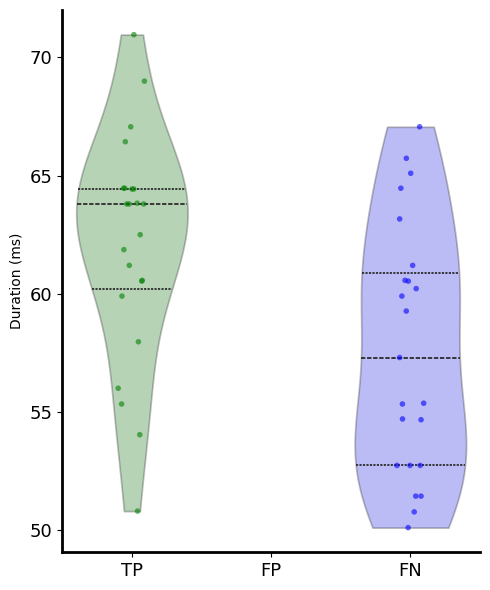

In [36]:
# Example Usage:
property='Duration_ms'
y_label="Duration (ms)"
y_lim=None
# y_lim=(-1,200)
fig=plot_single_property(properties_df[properties_df["Event_Type"].isin(["TP","FN"])], property, x='Event_Type', aggregate_by=aggregate_by, order=order, y_label=y_label, y_lim=y_lim, figsize=figsize)
summary_df, comparisons_df=get_single_property_summary(properties_df[properties_df["Event_Type"].isin(["TP","FN"])], property, group_col="Event_Type", aggregate_by=aggregate_by)

In [37]:
def plot_tp_vs_fn_histogram(df, prop, bins=30, ax=None):
    """
    Plots TP vs FN histograms with:
    - Shared bins
    - Percentage on y-axis
    - Median and quartile lines
    - Mann–Whitney U + Cliff's Delta
    """

    # Filter
    df_sub = df[df["Event_Type"].isin(["TP", "FN"])]

    v_tp = df_sub[df_sub["Event_Type"] == "TP"][prop].dropna().values
    v_fn = df_sub[df_sub["Event_Type"] == "FN"][prop].dropna().values

    if len(v_tp) == 0 or len(v_fn) == 0:
        print("One of the groups is empty.")
        return None

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    colors = {'TP': 'green', 'FN': 'blue'}

    # --- Shared bins ---
    data_all = np.concatenate([v_tp, v_fn])
    bin_edges = np.histogram_bin_edges(data_all, bins=bins)

    # --- Percentage weights ---
    weights_tp = np.ones_like(v_tp) * 100.0 / len(v_tp)
    weights_fn = np.ones_like(v_fn) * 100.0 / len(v_fn)

    # --- Plot histograms ---
    ax.hist(v_tp, bins=bin_edges, weights=weights_tp,
            alpha=0.3, label="TP",
            color=colors['TP'], edgecolor='black', linewidth=1.2)

    ax.hist(v_fn, bins=bin_edges, weights=weights_fn,
            alpha=0.3, label="FN",
            color=colors['FN'], edgecolor='black', linewidth=1.2)

    # --- Quartiles & Medians ---
    for values, label, color in [(v_tp, "TP", colors["TP"]),
                                 (v_fn, "FN", colors["FN"])]:

        q1 = np.percentile(values, 25)
        median = np.percentile(values, 50)
        q3 = np.percentile(values, 75)

        # ax.axvline(q1, color=color, linestyle="--", linewidth=1)
        ax.axvline(median, color=color, linestyle="-", linewidth=2)
        # ax.axvline(q3, color=color, linestyle="--", linewidth=1)
        ax.fill_betweenx([0,20],q1,q3,color=color,alpha=0.1,)

    # --- Statistics ---
    u, p = mannwhitneyu(v_tp, v_fn, alternative="two-sided")

    n1, n2 = len(v_tp), len(v_fn)
    cliff_delta = (2*u) / (n1*n2) - 1

    print("TP vs FN (Mann–Whitney U)")
    print(f"U = {u:.3f}")
    print(f"p = {p:.4e}")
    print(f"Cliff's Delta = {cliff_delta:.3f}")

    # --- Formatting ---
    ax.set_xlabel(prop)
    ax.set_ylabel("Percentage (%)")
    ax.legend()
    ax.spines[['right', 'top']].set_visible(False)

    plt.tight_layout()
    return fig

TP vs FN (Mann–Whitney U)
U = 113783454.000
p = 1.0869e-187
Cliff's Delta = 0.223


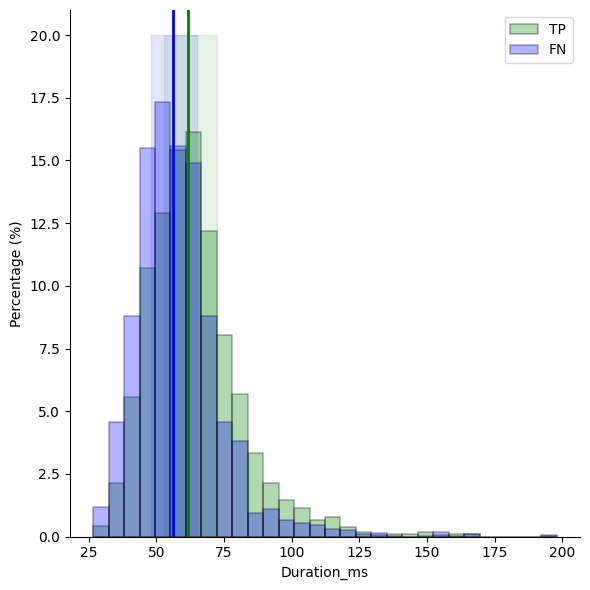

In [38]:
fig=plot_tp_vs_fn_histogram(properties_df, property, bins=30,  ax=None)

# Preferred Frequency

TP vs FP: Cliff's Delta = -1.000 (Large)
TP vs FN: Cliff's Delta = -1.000 (Large)
FP vs FN: Cliff's Delta = -1.000 (Large)
TP vs FP (Wilcox): p-value = 2.3842e-07 -> adj p-value = 7.1526e-07
TP vs FN (Wilcox): p-value = 2.3842e-07 -> adj p-value = 7.1526e-07
FP vs FN (Wilcox): p-value = 3.8392e-05 -> adj p-value = 3.8392e-05
Aggregating by ['Session'] -> N=69


C:\Users\NCN\AppData\Local\Temp\ipykernel_9560\656608900.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, palette=palette,boxprops=dict(alpha=.3),showfliers=False )
C:\Users\NCN\AppData\Local\Temp\ipykernel_9560\656608900.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, alpha=0.6, jitter=True, size=4, legend=False, palette=palette)


,Group,Median [IQR],Mean ± Std,N
0,FN,"110.00 [103.00, 124.00]",112.61 ± 12.11,23
1,FP,"98.00 [93.00, 102.00]",98.43 ± 7.18,23
2,TP,"134.00 [127.00, 139.00]",131.57 ± 12.31,23



--- Pairwise Comparisons ---


,p(FN vs FP),p(FN vs TP),p(FP vs TP)
0,3.84e-05 ***,2.38e-07 ***,2.38e-07 ***


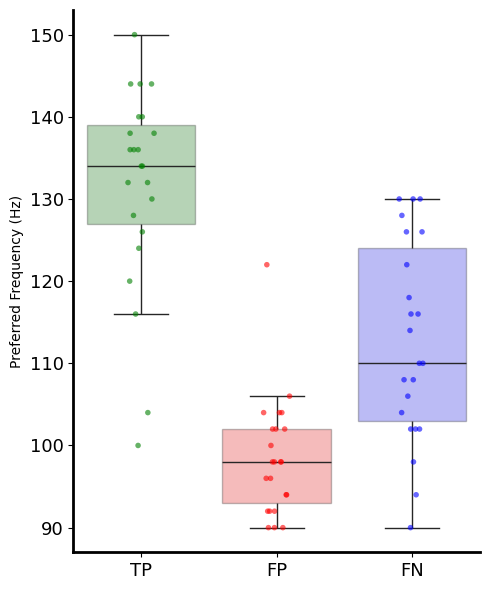

In [39]:
# Example Usage:
properties=['Duration_ms', 'Preferred_Freq', 'Low_Freq_Contrib', 'Entropy', 'Spike_Rate', 'Spike_Rate_within_Event']
property='Preferred_Freq'
y_label="Preferred Frequency (Hz)"
y_lim=None
boxplot=True
# y_lim=(80,160)
fig=plot_single_property(properties_df, property, x='Event_Type', aggregate_by=aggregate_by, order=order, y_label=y_label, y_lim=y_lim, figsize=figsize,boxplot=boxplot)
summary_df, comparisons_df=get_single_property_summary(properties_df, property, group_col="Event_Type", aggregate_by=aggregate_by)

### Low Frequency Contribution

TP vs FP: Cliff's Delta = -0.943 (Large)
TP vs FN: Cliff's Delta = -0.951 (Large)
FP vs FN: Cliff's Delta = -0.705 (Large)
TP vs FP (Wilcox): p-value = 3.2663e-05 -> adj p-value = 6.5327e-05
TP vs FN (Wilcox): p-value = 2.0981e-05 -> adj p-value = 6.2943e-05
FP vs FN (Wilcox): p-value = 6.9817e-02 -> adj p-value = 6.9817e-02
Aggregating by ['Session'] -> N=69


C:\Users\NCN\AppData\Local\Temp\ipykernel_9560\656608900.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, inner="quart", alpha=0.3, cut=0, palette=palette)
C:\Users\NCN\AppData\Local\Temp\ipykernel_9560\656608900.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, alpha=0.6, jitter=True, size=4, legend=False, palette=palette)


,Group,Median [IQR],Mean ± Std,N
0,FN,"0.89 [0.86, 0.90]",0.88 ± 0.04,23
1,FP,"0.90 [0.88, 0.91]",0.89 ± 0.03,23
2,TP,"0.85 [0.82, 0.87]",0.85 ± 0.05,23



--- Pairwise Comparisons ---


,p(FN vs FP),p(FN vs TP),p(FP vs TP)
0,0.0698,2.10e-05 ***,3.27e-05 ***


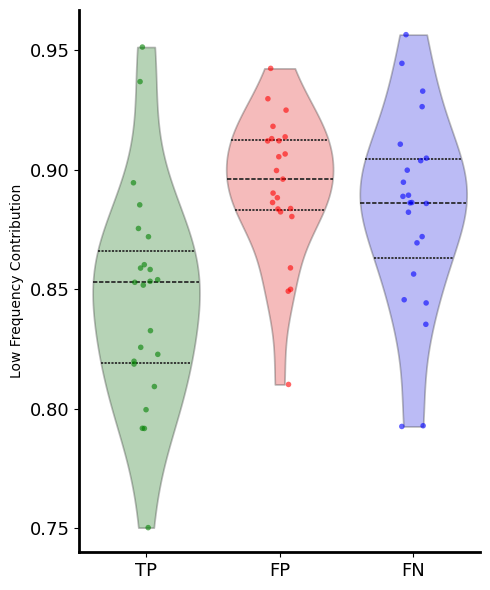

In [40]:
# Example Usage:
property='Low_Freq_Contrib'
y_label="Low Frequency Contribution"
# y_lim=(0,1)
y_lim=None
fig=plot_single_property(properties_df, property, x='Event_Type', aggregate_by=aggregate_by, order=order, y_label=y_label, y_lim=y_lim, figsize=figsize)
summary_df, comparisons_df=get_single_property_summary(properties_df, property, group_col="Event_Type", aggregate_by=aggregate_by)

### Spectral Entropy

TP vs FP: Cliff's Delta = -0.618 (Large)
TP vs FN: Cliff's Delta = -0.834 (Large)
FP vs FN: Cliff's Delta = -0.682 (Large)
TP vs FP (Wilcox): p-value = 2.7258e-01 -> adj p-value = 2.7258e-01
TP vs FN (Wilcox): p-value = 3.0708e-03 -> adj p-value = 9.2125e-03
FP vs FN (Wilcox): p-value = 1.0454e-01 -> adj p-value = 2.0909e-01
Aggregating by ['Session'] -> N=69


C:\Users\NCN\AppData\Local\Temp\ipykernel_9560\656608900.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, inner="quart", alpha=0.3, cut=0, palette=palette)
C:\Users\NCN\AppData\Local\Temp\ipykernel_9560\656608900.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, alpha=0.6, jitter=True, size=4, legend=False, palette=palette)


,Group,Median [IQR],Mean ± Std,N
0,FN,"3.68 [3.54, 3.77]",3.67 ± 0.16,23
1,FP,"3.61 [3.56, 3.74]",3.61 ± 0.23,23
2,TP,"3.56 [3.53, 3.63]",3.59 ± 0.09,23



--- Pairwise Comparisons ---


,p(FN vs FP),p(FN vs TP),p(FP vs TP)
0,0.1045,0.0031 **,0.2726


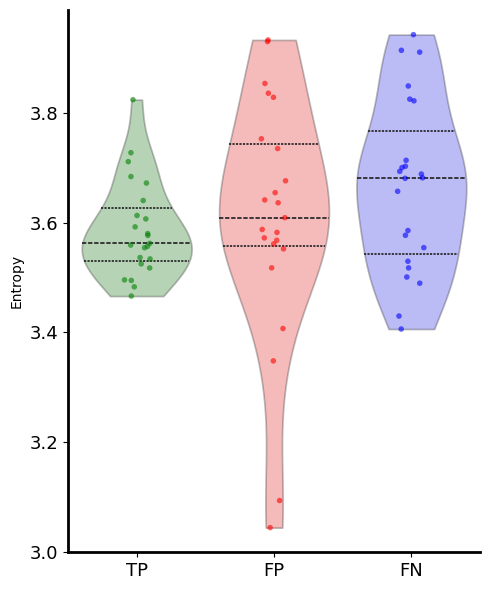

In [41]:
property='Entropy'
y_label="Entropy"

fig=plot_single_property(properties_df, property, x='Event_Type', aggregate_by=aggregate_by, order=order, y_label=y_label,figsize=figsize)
summary_df, comparisons_df=get_single_property_summary(properties_df, property, group_col="Event_Type", aggregate_by=aggregate_by)

### Spike Rate

TP vs FP: Cliff's Delta = -1.000 (Large)
TP vs FN: Cliff's Delta = -1.000 (Large)
FP vs FN: Cliff's Delta = -0.866 (Large)
TP vs FP (Wilcox): p-value = 2.3842e-07 -> adj p-value = 7.1526e-07
TP vs FN (Wilcox): p-value = 2.3842e-07 -> adj p-value = 7.1526e-07
FP vs FN (Wilcox): p-value = 4.8474e-03 -> adj p-value = 4.8474e-03
Aggregating by ['Session'] -> N=69


C:\Users\NCN\AppData\Local\Temp\ipykernel_9560\656608900.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, inner="quart", alpha=0.3, cut=0, palette=palette)
C:\Users\NCN\AppData\Local\Temp\ipykernel_9560\656608900.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, alpha=0.6, jitter=True, size=4, legend=False, palette=palette)


,Group,Median [IQR],Mean ± Std,N
0,FN,"170.00 [150.00, 200.00]",175.65 ± 30.43,23
1,FP,"200.00 [175.00, 210.00]",192.61 ± 23.59,23
2,TP,"300.00 [265.00, 320.00]",293.04 ± 43.43,23



--- Pairwise Comparisons ---


,p(FN vs FP),p(FN vs TP),p(FP vs TP)
0,0.0048 **,2.38e-07 ***,2.38e-07 ***


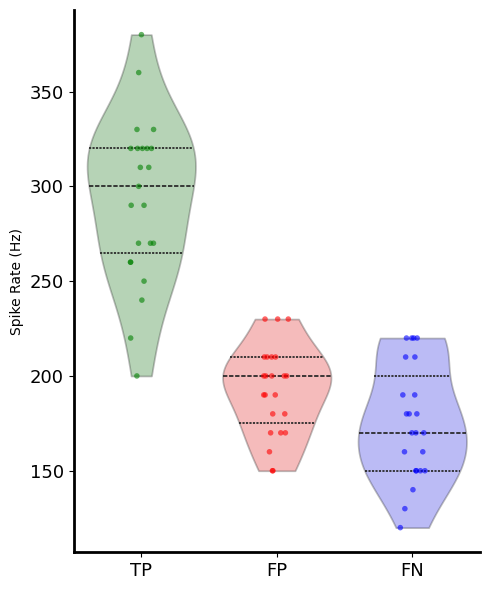

In [42]:
property="Spike_Rate"
y_label="Spike Rate (Hz)"

fig=plot_single_property(properties_df, property, x='Event_Type', aggregate_by=aggregate_by, order=order, y_label=y_label,figsize=figsize)
summary_df, comparisons_df=get_single_property_summary(properties_df, property, group_col="Event_Type", aggregate_by=aggregate_by)

C:\Users\NCN\AppData\Local\Temp\ipykernel_9560\656608900.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, inner="quart", alpha=0.3, cut=0, palette=palette)


TP vs FP: Cliff's Delta = 0.548 (Large)
TP vs FN: Cliff's Delta = 0.767 (Large)
FP vs FN: Cliff's Delta = 0.330 (Small)
TP vs FP (MWU): p-value = 0.0000e+00 -> adj p-value = 0.0000e+00
TP vs FN (MWU): p-value = 0.0000e+00 -> adj p-value = 0.0000e+00
FP vs FN (MWU): p-value = 0.0000e+00 -> adj p-value = 0.0000e+00


,Group,Median [IQR],Mean ± Std,N
0,FN,"16.00 [11.00, 20.00]",16.26 ± 7.21,7362
1,FP,"20.00 [15.00, 25.00]",20.91 ± 8.73,33700
2,TP,"29.00 [23.00, 38.00]",31.40 ± 11.61,25266



--- Pairwise Comparisons ---


,p(FN vs FP),p(FN vs TP),p(FP vs TP)
0,0.00e+00 ***,0.00e+00 ***,0.00e+00 ***


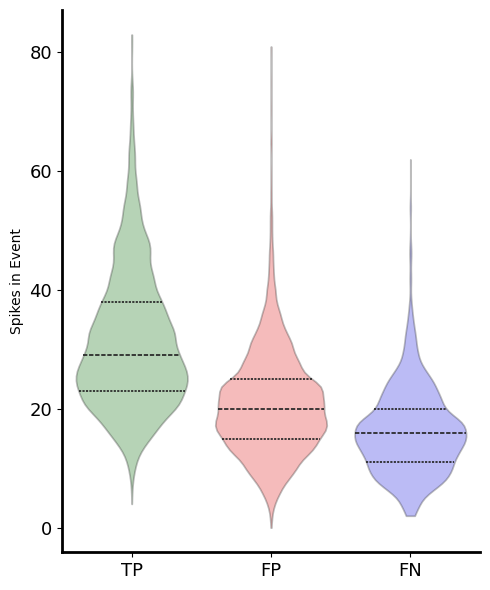

In [28]:
# Spike Number 
property="Spike_Number"
y_label="Spikes in Event"

fig=plot_single_property(properties_df, property, x='Event_Type', aggregate_by=aggregate_by, order=order, y_label=y_label,figsize=figsize)
summary_df, comparisons_df=get_single_property_summary(properties_df, property, group_col="Event_Type", aggregate_by=aggregate_by)

# Radar Plots...


In [29]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections import register_projection
from matplotlib.projections.polar import PolarAxes
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D


def radar_factory(num_vars, frame='circle'):
    """
    Create a radar chart with `num_vars` Axes.

    This function creates a RadarAxes projection and registers it.

    Parameters
    ----------
    num_vars : int
        Number of variables for radar chart.
    frame : {'circle', 'polygon'}
        Shape of frame surrounding Axes.

    """
    # calculate evenly-spaced axis angles
    theta = np.linspace(0, 2*np.pi, num_vars, endpoint=False)

    class RadarTransform(PolarAxes.PolarTransform):

        def transform_path_non_affine(self, path):
            # Paths with non-unit interpolation steps correspond to gridlines,
            # in which case we force interpolation (to defeat PolarTransform's
            # autoconversion to circular arcs).
            if path._interpolation_steps > 1:
                path = path.interpolated(num_vars)
            return Path(self.transform(path.vertices), path.codes)

    class RadarAxes(PolarAxes):

        name = 'radar'
        PolarTransform = RadarTransform

        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            # rotate plot such that the first axis is at the top
            self.set_theta_zero_location('N')

        def fill(self, *args, closed=True, **kwargs):
            """Override fill so that line is closed by default"""
            return super().fill(closed=closed, *args, **kwargs)

        def plot(self, *args, **kwargs):
            """Override plot so that line is closed by default"""
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)

        def _close_line(self, line):
            x, y = line.get_data()
            # FIXME: markers at x[0], y[0] get doubled-up
            if x[0] != x[-1]:
                x = np.append(x, x[0])
                y = np.append(y, y[0])
                line.set_data(x, y)

        def set_varlabels(self, labels):
            self.set_thetagrids(np.degrees(theta), labels)

        def _gen_axes_patch(self):
            # The Axes patch must be centered at (0.5, 0.5) and of radius 0.5
            # in axes coordinates.
            if frame == 'circle':
                return Circle((0.5, 0.5), 0.5)
            elif frame == 'polygon':
                return RegularPolygon((0.5, 0.5), num_vars,
                                      radius=.5, edgecolor="k")
            else:
                raise ValueError("Unknown value for 'frame': %s" % frame)

        def _gen_axes_spines(self):
            if frame == 'circle':
                return super()._gen_axes_spines()
            elif frame == 'polygon':
                # spine_type must be 'left'/'right'/'top'/'bottom'/'circle'.
                spine = Spine(axes=self,
                              spine_type='circle',
                              path=Path.unit_regular_polygon(num_vars))
                # unit_regular_polygon gives a polygon of radius 1 centered at
                # (0, 0) but we want a polygon of radius 0.5 centered at (0.5,
                # 0.5) in axes coordinates.
                spine.set_transform(Affine2D().scale(.5).translate(.5, .5)
                                    + self.transAxes)
                return {'polar': spine}
            else:
                raise ValueError("Unknown value for 'frame': %s" % frame)

    register_projection(RadarAxes)
    return theta

In [43]:

def radar_plot_event_types(df_power, df_properties, metrics, category_col='Event_Type', aggregate_by=None):
    """
    Creates a radar chart comparing categories in `category_col` across `metrics`.
    Merges df_power and df_properties based on available metrics.
    
    Args:
        df_power: DataFrame containing the power data.
        df_properties: DataFrame containing the properties data.
        metrics: List of column names to plot.
        category_col: Column defining the groups to compare (e.g., 'Event_Type').
        aggregate_by: List of columns to aggregate (median) by before plotting (e.g., ['Session']).
    """
    # Create working copies
    df_power_plot = df_power.copy() if df_power is not None else pd.DataFrame()
    df_properties_plot = df_properties.copy() if df_properties is not None else pd.DataFrame()
    
    # Identify which df holds which metric
    power_metrics = [m for m in metrics if m in df_power_plot.columns]
    prop_metrics = [m for m in metrics if m in df_properties_plot.columns]
    
    # 1. Aggregation if requested
    if aggregate_by:
        group_keys = set(aggregate_by)
        if category_col:
            # We MUST include the category column in the grouping, otherwise we lose the distinction between categories!
            group_keys.add(category_col)
             
        group_keys = list(group_keys)
        print(f"Radar Plot: Aggregating data by {group_keys} before plotting...")

        if len(df_power_plot) > 0 and power_metrics:
             # Ensure group keys exist
            valid_keys = [k for k in group_keys if k in df_power_plot.columns]
            if valid_keys:
                df_power_plot = df_power_plot.groupby(valid_keys)[power_metrics].median().reset_index()

        if len(df_properties_plot) > 0 and prop_metrics:
            valid_keys = [k for k in group_keys if k in df_properties_plot.columns]
            if valid_keys:
                df_properties_plot = df_properties_plot.groupby(valid_keys)[prop_metrics].median().reset_index()
    
    # display(df_properties_plot.head())

    # 2. Normalize metrics (0-1)
    metrics_labels = []
    
    # Get all categories
    categories = set()
    if category_col in df_power_plot.columns:
        categories.update(df_power_plot[category_col].unique())
    if category_col in df_properties_plot.columns:
        categories.update(df_properties_plot[category_col].unique())
    categories = sorted(list(categories))
    
    # Store normalization ranges to creating labels
    norm_ranges = {} 

    for metric in metrics:
        # Determine which DF has this metric
        target_df = None
        if metric in df_power_plot.columns:
            target_df = df_power_plot
        elif metric in df_properties_plot.columns:
            target_df = df_properties_plot
            
        if target_df is None:
            print(f"Warning: Metric {metric} not found in either DataFrame.")
            metrics_labels.append(metric)
            continue
        else:
            # Compute min/max for normalization
            
            # Group by category first, calculate quantile for each category, then find min/max of those quantiles
            lower_bounds = target_df.groupby([category_col])[metric].quantile(0)
            upper_bounds = target_df.groupby([category_col])[metric].quantile(0.75)
            
            min_val = min(lower_bounds)
            max_val = max(upper_bounds)
            
            
        norm_ranges[metric] = (min_val, max_val)
        
        # Create normalized column
        col_name_norm = metric + "_norm"
        if max_val - min_val > 0:
            target_df[col_name_norm] = (target_df[metric] - min_val) / (max_val - min_val)
        else:
            target_df[col_name_norm] = 0.5

        # Create label
        label = metric.replace("_", " ")
        label += f"\n[{min_val:.2f}, {max_val:.2f}]"
        metrics_labels.append(label)

    # 3. Collect Data fo    wwwr Plotting
    stats = {}
    
    for cat in categories:
        cat_stats = {'median': [], '25%': [], '75%': []}
        
        for metric in metrics:
            target_df = None
            if metric in df_power_plot.columns: target_df = df_power_plot
            elif metric in df_properties_plot.columns: target_df = df_properties_plot
            
            if target_df is not None:
                # Filter by category
                if category_col in target_df.columns:
                    group = target_df[target_df[category_col] == cat]
                else:
                    group = pd.DataFrame() # Should not happen if logic is correct
                
                col_norm = metric + "_norm"
                if col_norm in group.columns:
                    vals = group[col_norm]
                    if len(vals) > 0:
                        cat_stats['median'].append(vals.median())
                        cat_stats['25%'].append(vals.quantile(0.25))
                        cat_stats['75%'].append(vals.quantile(0.75))
                    else:
                        cat_stats['median'].append(0)
                        cat_stats['25%'].append(0)
                        cat_stats['75%'].append(0)
                else:
                     # Missing norm column?
                    cat_stats['median'].append(0)
                    cat_stats['25%'].append(0)
                    cat_stats['75%'].append(0)
            else:
                cat_stats['median'].append(0)
                cat_stats['25%'].append(0)
                cat_stats['75%'].append(0)
        
        stats[cat] = cat_stats

    # 4. Plot
    if 'radar_factory' not in globals():
        print("Error: radar_factory not defined")
        return None, None

    theta = radar_factory(len(metrics), frame='polygon')
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='radar'))
    
    ax.set_rgrids([0.2, 0.4, 0.6, 0.8])
    ax.set_title(f"Metrics Profile by {category_col}", weight='bold', size='large', position=(0.5, 1.1))

    colors = {'TP': 'green', 'FP': 'red', 'FN': 'blue'}
    
    for cat in categories:
        c = colors.get(cat, None)
        data = stats[cat]
        
        if not data['median']: continue 

        values_med = data['median']
        values_25 = data['25%']
        values_75 = data['75%']
        
        # Plot Median
        ax.plot(theta, values_med, color=c, lw=2, label=cat)
        
        # Fill IQR
        ax.fill_between(np.append(theta, theta[0]), 
                        np.append(values_25, values_25[0]), 
                        np.append(values_75, values_75[0]), 
                        color=c, alpha=0.1)
        
        ax.plot(theta, values_25, color=c, lw=1, ls='--',alpha=0.5)
        ax.plot(theta, values_75, color=c, lw=1, ls='--',alpha=0.5)

    ax.set_varlabels(metrics_labels)
    ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))

    plt.show()
    return fig, ax

In [44]:

from scipy.stats import mannwhitneyu
import pandas as pd
import numpy as np
import itertools

def compute_stats_table(df_power, df_properties, category_col='Event_Type', aggregate_by_session=False, metrics_to_use=["Duration_ms", "Fraction_over_80ms", "Peak_Power_Z", "Mean_Power_Z", "Preferred_Freq", "Entropy"], top_percentile=0.75):
    
    # 1. Align DataFrames 
    df_p = df_power.copy() if df_power is not None else pd.DataFrame()
    df_prop = df_properties.copy() if df_properties is not None else pd.DataFrame()

    # 2. Filter by Top Percentile of Duration (if Duration_ms exists)
    for d in [df_p, df_prop]:
        if 'Duration_ms' in d.columns and not d.empty:
             if 'Session' in d.columns:
                 # Calculate percentile on the fly
                 d_filtered = d.groupby('Session').apply(lambda x: x[x['Duration_ms'] >= x['Duration_ms'].quantile(top_percentile)])
                 d_filtered = d_filtered.reset_index(drop=True)
                 
                 # update the dataframe in place if possible, but safer to reassign
                 if d is df_p: df_p = d_filtered
                 else: df_prop = d_filtered

    # Prepare list for rows
    results = []

    # Get unique categories to compare
    categories = set()
    if category_col in df_p.columns:
        categories.update(df_p[category_col].unique())
    if category_col in df_prop.columns:
        categories.update(df_prop[category_col].unique())
    
    categories = sorted([str(c) for c in categories])
    comparisons = list(itertools.combinations(categories, 2))
    
    print(f"Categories found: {categories}")

    for metric in metrics_to_use:
        row = {'Metric': metric}
        
        # Locate metric dataframe
        source_df = None
        if metric in df_p.columns:
            source_df = df_p
        elif metric in df_prop.columns:
            source_df = df_prop
        
        if source_df is None or source_df.empty:
            continue

        # Data extraction logic
        session_based_vars = ["Fraction_over_80ms", "Fraction_over_100ms", "Ripple_Rate"] 
        group_cols = ['Session', category_col]
        group_cols = [c for c in group_cols if c in source_df.columns]
        
        if aggregate_by_session:
            if metric in session_based_vars:
                 df_metric = source_df.groupby(group_cols)[metric].first().reset_index()
            else:
                 df_metric = source_df.groupby(group_cols)[metric].median().reset_index()
        else:
             if metric in session_based_vars:
                 df_metric = source_df.groupby(group_cols)[metric].first().reset_index()
             else:
                 extract_cols = group_cols + [metric]
                 df_metric = source_df[extract_cols].copy()

        # 1. Calculate Per-Category Stats (Median + IQR)
        metric_values = {}
        for cat in categories:
            vals = df_metric[df_metric[category_col] == cat][metric].dropna().values
            metric_values[cat] = vals
            
            if len(vals) > 0:
                med = np.median(vals)
                q1 = np.percentile(vals, 25)
                q3 = np.percentile(vals, 75)
                # Formatted column
                row[f"{cat} Median (IQR)"] = f"{med:.2f} ({q1:.2f}-{q3:.2f})"
            else:
                row[f"{cat} Median (IQR)"] = "ND"

        # 2. Calculate Pairwise Comparisons
        for cat1, cat2 in comparisons:
            vals1 = metric_values.get(cat1, [])
            vals2 = metric_values.get(cat2, [])
            
            p_val = np.nan
            d_val = np.nan
            effect = "-"

            if len(vals1) > 0 and len(vals2) > 0:  
                if aggregate_by_session:
                    try:
                        #match on session for paired test
                        merge_keys = ['Session'] if 'Session' in df_metric.columns else []
                        d1 = df_metric[df_metric[category_col] == cat1]
                        d2 = df_metric[df_metric[category_col] == cat2]
                        merged = pd.merge(d1, d2, on=merge_keys, suffixes=('_1', '_2'), how='inner')
                        v1 = merged[metric + '_1'].dropna()
                        v2 = merged[metric + '_2'].dropna()

                        u_stat, p_val = wilcoxon(v1, v2)
                        d_val, effect = cliffs_delta(u_stat, len(vals1), len(vals2))
                        print(f"{cat1} vs {cat2} on {metric}: Wilcoxon p={p_val:.4e}, Cliff's d={d_val:.3f} ({effect})")
                    except Exception as e:
                        print(f"Error in Wilcoxon test for {cat1} vs {cat2} on {metric}: {e}")
                        p_val = np.nan
                else:
                    try:
                        u_stat, p_val = mannwhitneyu(vals1, vals2, alternative='two-sided')
                        
                        # Cliff's Delta
                        d_val, effect = cliffs_delta(u_stat, len(vals1), len(vals2))
                    except ValueError:
                        p_val = np.nan
            
            # Format p-value
            if np.isnan(p_val):
                p_str = "ND"
            else:
                p_str = f"{p_val:.2e}" if p_val < 0.0001 else f"{p_val:.3f}"
                if p_val < 0.05: p_str += "*"
                if p_val < 0.01: p_str += "*"
                if p_val < 0.001: p_str += "*"
            
            # Format Effect Size
            d_str = f"{d_val:.2f} ({effect})" if not np.isnan(d_val) else "ND"

            comp_name = f"{cat1} vs {cat2}"
            row[f"{comp_name} p-val"] = p_str
            row[f"{comp_name} Cliff's d"] = d_str

        results.append(row)

    return pd.DataFrame(results)


Radar Plot: Aggregating data by ['Session', 'Event_Type'] before plotting...


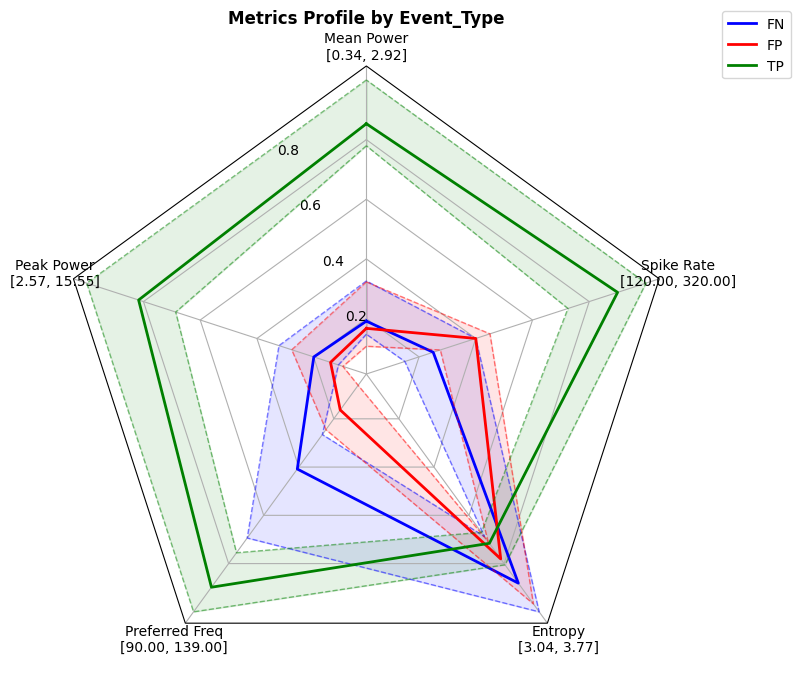

In [47]:
df.rename(columns={"Type":"Event_Type"}, inplace=True)
metrics=['Mean Power','Peak Power', "Preferred_Freq",  'Entropy', 'Spike_Rate']

aggregate_by=["Session"]
# aggregate_by=None
fig,ax=radar_plot_event_types(df, properties_df, metrics, category_col='Event_Type', aggregate_by=aggregate_by)
fig.savefig(f"figures/radar_plot_{aggregate_by}.png", dpi=500, bbox_inches='tight')
fig.savefig(f"figures/radar_plot_{aggregate_by}.svg", dpi=500, bbox_inches='tight')

In [33]:
print("Re-computing statistics table with updated function...")
try:
    aggregate_by_session=(aggregate_by is not None and "Session" in aggregate_by)
    stats_df_new = compute_stats_table(df, properties_df, metrics_to_use=metrics, aggregate_by_session=aggregate_by_session, top_percentile=0)
    display(stats_df_new)
except Exception as e:
    print(f"Error computing stats table: {e}")
    # print columns for debugging
    print("df columns:", df.columns.tolist())
    print("properties_df columns:", properties_df.columns.tolist())

Re-computing statistics table with updated function...
Categories found: ['FN', 'FP', 'TP']


C:\Users\NCN\AppData\Local\Temp\ipykernel_9560\2090448900.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  d_filtered = d.groupby('Session').apply(lambda x: x[x['Duration_ms'] >= x['Duration_ms'].quantile(top_percentile)])


,Metric,FN Median (IQR),FP Median (IQR),TP Median (IQR),FN vs FP p-val,FN vs FP Cliff's d,FN vs TP p-val,FN vs TP Cliff's d,FP vs TP p-val,FP vs TP Cliff's d
0,Mean Power,0.87 (0.49-1.45),0.75 (0.42-1.24),2.49 (1.46-4.19),3.78e-42***,0.10 (Negligible),0.00e+00***,-0.68 (Large),0.00e+00***,-0.74 (Large)
1,Peak Power,5.24 (3.33-8.56),4.35 (2.91-6.90),12.78 (8.01-20.79),3.99e-77***,0.14 (Negligible),0.00e+00***,-0.64 (Large),0.00e+00***,-0.72 (Large)
2,Preferred_Freq,108.00 (86.00-132.00),98.00 (80.00-120.00),134.00 (116.00-148.00),8.81e-103***,0.16 (Small),0.00e+00***,-0.40 (Medium),0.00e+00***,-0.53 (Large)
3,Entropy,3.63 (3.37-3.86),3.61 (3.31-3.87),3.58 (3.36-3.77),5.38e-07***,0.04 (Negligible),2.70e-39***,0.10 (Negligible),2.07e-26***,0.05 (Negligible)
4,Spike_Rate,160.00 (110.00-200.00),200.00 (150.00-250.00),290.00 (230.00-380.00),0.00e+00***,-0.33 (Small),0.00e+00***,-0.77 (Large),0.00e+00***,-0.55 (Large)
